# NLP Challenge: Fake News Detection

### Overview
Build a machine learning classifier to distinguish between **Real (1)** and **Fake (0)** news headlines.

### Data
* **Training:** `training_data_lowercase.csv` (labeled).
* **Validation:** `testing_data_lowercase_nolabels.csv` (label `2` to be predicted).

### Objectives
* Preprocess text (clean noise, remove stopwords).
* Convert text to numerical vectors.
* Train and evaluate a classifier.
* Generate final predictions for the validation set.

## 1. Importing Libraries and Loading Data

In [51]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Visuals & Metrics
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Vectorization & Models
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Setup NLTK
nltk.download('stopwords')
nltk.download('wordnet')

print("Environment Ready.")

Environment Ready.


[nltk_data] Downloading package stopwords to /Users/rima/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/rima/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [52]:
# Load Training Data
train_df = pd.read_csv('training_data_lowercase.csv', sep='\t', header=None, names=['label', 'text'])

# Load Validation Data (The one to predict)
val_df = pd.read_csv('testing_data_lowercase_nolabels.csv', sep='\t', header=None, names=['label', 'text'])

print(f"Training shapes: {train_df.shape}")
print(train_df.head())

Training shapes: (34152, 2)
   label                                               text
0      0  donald trump sends out embarrassing new year‚s...
1      0  drunk bragging trump staffer started russian c...
2      0  sheriff david clarke becomes an internet joke ...
3      0  trump is so obsessed he even has obama‚s name ...
4      0  pope francis just called out donald trump duri...


## 2. Data Preprocessing
1. **Cleaning**: Remove special characters (like `‚`, `…`), punctuation, and numbers.
2. **Stopwords Removal**: Remove common words (e.g., "the", "is") that do not add predictive value.

In [53]:
stop_words = set(stopwords.words('english'))

def final_clean_no_dates(text):
    # 1. Convert to lowercase
    text = str(text).lower()
    
    # 2. Strict Regex: Remove everything except letters (a-z) and spaces
    # This specifically deletes numbers (0-9) and punctuation
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 3. Tokenize and remove stopwords
    words = text.split()
    cleaned_words = [w for w in words if w not in stop_words]
    
    return " ".join(cleaned_words)

# Apply cleaning to both datasets
train_df['preprocessed_text'] = train_df['text'].apply(final_clean_no_dates)
val_df['preprocessed_text'] = val_df['text'].apply(final_clean_no_dates)

# Verification: Print 10 samples of each category

# Select indices for 10 Fake (0) and 10 Real (1) articles
fake_indices = train_df[train_df['label'] == 0].head(5).index.tolist()
real_indices = train_df[train_df['label'] == 1].head(5).index.tolist()
all_indices = fake_indices + real_indices

print(f"{'LBL':<4} | {'TYPE':<6} | {'ORIGINAL TEXT':<50} | {'CLEANED (NO DATES)'}")
print("-" * 145)

for i in all_indices:
    label = train_df['label'].iloc[i]
    original = train_df['text'].iloc[i]
    cleaned = train_df['preprocessed_text'].iloc[i]
    
    label_text = "FAKE" if label == 0 else "REAL"
    # Truncate original text for better display
    orig_short = (original[:47] + '..') if len(original) > 47 else original
    
    print(f"{label:<4} | {label_text:<6} | {orig_short:<50} | {cleaned}")
    #print(f"{label:<4} | {label_text:<6} | {cleaned}")

LBL  | TYPE   | ORIGINAL TEXT                                      | CLEANED (NO DATES)
-------------------------------------------------------------------------------------------------------------------------------------------------
0    | FAKE   | donald trump sends out embarrassing new year‚s ..  | donald trump sends embarrassing new years eve message disturbing
0    | FAKE   | drunk bragging trump staffer started russian co..  | drunk bragging trump staffer started russian collusion investigation
0    | FAKE   | sheriff david clarke becomes an internet joke f..  | sheriff david clarke becomes internet joke threatening poke people eye
0    | FAKE   | trump is so obsessed he even has obama‚s name c..  | trump obsessed even obamas name coded website images
0    | FAKE   | pope francis just called out donald trump durin..  | pope francis called donald trump christmas speech
1    | REAL   | as u.s. budget fight looms	republicans flip the..  | us budget fight looms republicans flip fisca

## 3. Stemming
To further refine the dataset, the **Snowball Stemmer** (also known as Porter2) was applied. 
This process reduces words to their linguistic roots by removing common suffixes.

**Key objectives of this step:**
* **Feature Consolidation**: Different grammatical forms of the same word (e.g., "reporting", "reported", "reports") are mapped to a single stem ("report").
* **Dimensionality Reduction**: By grouping similar words, the total number of unique features is decreased, making the model more efficient.
* **Noise Reduction**: Irrelevant morphological variations are stripped away to focus on the core meaning of the terms.

In [54]:
## 3. Stemming Implementation
from nltk.stem import SnowballStemmer

# Initialize the Snowball Stemmer for the English language
stemmer = SnowballStemmer("english")

def apply_snowball_stemming(text):
    # Words are split, stemmed individually, and reconstructed into a string
    words = text.split()
    stemmed_words = [stemmer.stem(w) for w in words]
    return " ".join(stemmed_words)

# Stemming is applied to the preprocessed (cleaned) text
train_df['stemmed_text'] = train_df['preprocessed_text'].apply(apply_snowball_stemming)
val_df['stemmed_text'] = val_df['preprocessed_text'].apply(apply_snowball_stemming)

# Verification of the transformation
fake_indices = train_df[train_df['label'] == 0].head(10).index.tolist()
real_indices = train_df[train_df['label'] == 1].head(10).index.tolist()
selected_indices = fake_indices + real_indices

print(f"{'LBL':<4} | {'TYPE':<6} | {'SNOWBALL STEMMED TEXT'}")
print("-" * 120)

for i in selected_indices:
    label = train_df['label'].iloc[i]
    label_text = "FAKE" if label == 0 else "REAL"
    stemmed = train_df['stemmed_text'].iloc[i]
    
    # We print the full stemmed text to see the algorithm's effect
    print(f"{label:<4} | {label_text:<6} | {stemmed}")

LBL  | TYPE   | SNOWBALL STEMMED TEXT
------------------------------------------------------------------------------------------------------------------------
0    | FAKE   | donald trump send embarrass new year eve messag disturb
0    | FAKE   | drunk brag trump staffer start russian collus investig
0    | FAKE   | sheriff david clark becom internet joke threaten poke peopl eye
0    | FAKE   | trump obsess even obama name code websit imag
0    | FAKE   | pope franci call donald trump christma speech
0    | FAKE   | racist alabama cop brutal black boy handcuff graphic imag
0    | FAKE   | fresh golf cours
0    | FAKE   | trump said insan racist stuff insid oval offic
0    | FAKE   | former cia director slam trump un bulli
0    | FAKE   | brandnew protrump ad featur much kiss make sick
1    | REAL   | us budget fight loom republican flip fiscal script
1    | REAL   | us militari accept transgend recruit monday pentagon
1    | REAL   | senior us republican senat let mr mueller job
1    |

## 3.2. Visualizing Word Frequencies (Fake vs Real)
To understand the linguistic differences between the two classes, we visualize the most frequent words (stems) using both **Bar Charts** and **Word Clouds**.

### **Key Observations:**
* **FAKE News Dominance**: Words like `"video"`, `"obama"`, and `"hillari"` appear significantly more often in fake news. The high frequency of `"video"` suggests that fake content in this dataset often points to sensationalist visual media.
* **REAL News Dominance**: Official reporting terms such as `"say"`, `"hous"`, `"senat"`, and `"republican"` are more prevalent in real news, reflecting a more formal and institutional tone.
* **Shared Vocabulary**: The term `"trump"` is the most frequent word in both categories, indicating it is a neutral topic word rather than a strong class indicator on its own.

/var/folders/_w/q8p_cs1d7nz7tsmlmhpvk1zc0000gn/T/ipykernel_63433/2553964876.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts_f), y=list(words_f), ax=axes[0, 0], palette='Reds_r')
/var/folders/_w/q8p_cs1d7nz7tsmlmhpvk1zc0000gn/T/ipykernel_63433/2553964876.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts_r), y=list(words_r), ax=axes[1, 0], palette='Blues_r')


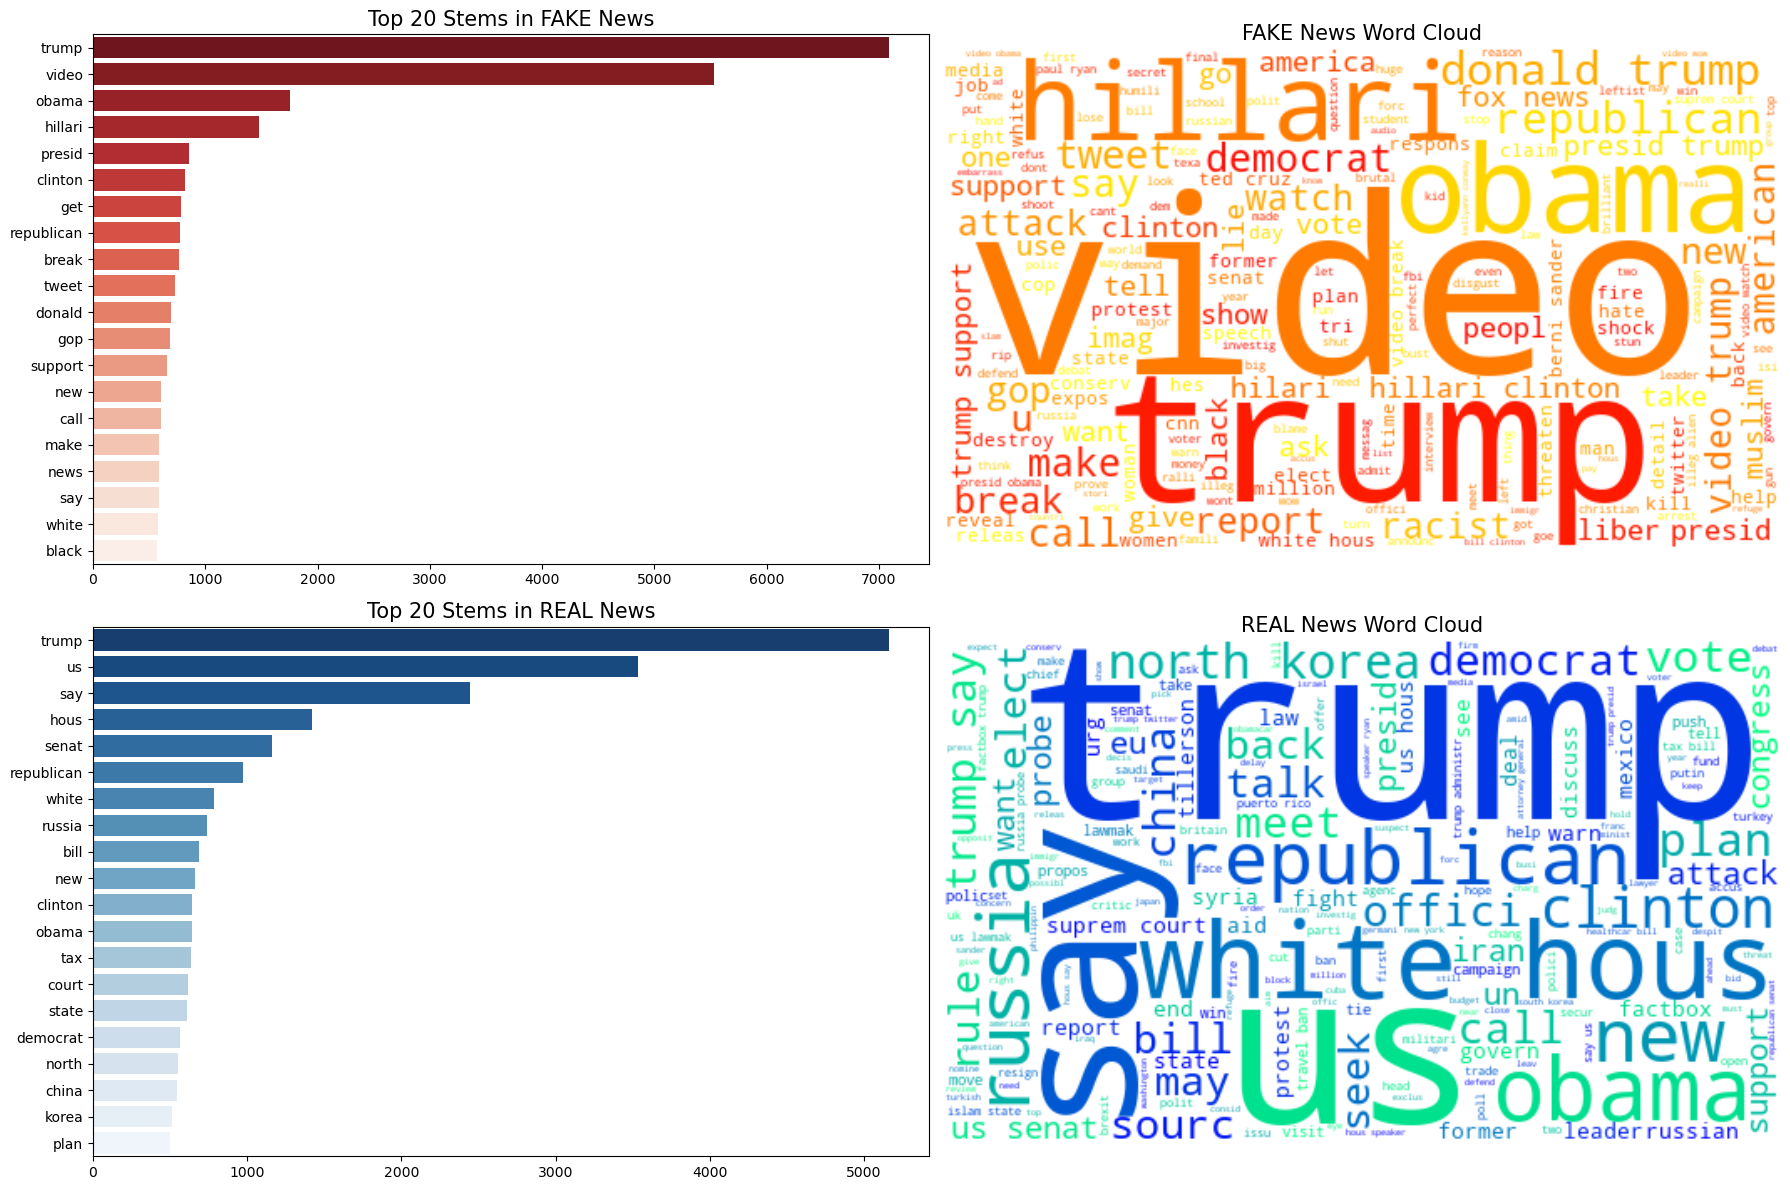

In [55]:
!pip install wordcloud
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# 1. Function to get top N words
def get_top_words(df, label, n=20):
    text = " ".join(df[df['label'] == label]['stemmed_text']).split()
    return Counter(text).most_common(n)

# 2. Setup the visualization area
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# --- FAKE NEWS VISUALS ---
fake_top_20 = get_top_words(train_df, 0)
words_f, counts_f = zip(*fake_top_20)
sns.barplot(x=list(counts_f), y=list(words_f), ax=axes[0, 0], palette='Reds_r')
axes[0, 0].set_title('Top 20 Stems in FAKE News', fontsize=15)

fake_text = " ".join(train_df[train_df['label'] == 0]['stemmed_text'])
wc_fake = WordCloud(width=500, height=300, background_color='white', colormap='autumn').generate(fake_text)
axes[0, 1].imshow(wc_fake, interpolation='bilinear')
axes[0, 1].set_title('FAKE News Word Cloud', fontsize=15)
axes[0, 1].axis('off')

# --- REAL NEWS VISUALS ---
real_top_20 = get_top_words(train_df, 1)
words_r, counts_r = zip(*real_top_20)
sns.barplot(x=list(counts_r), y=list(words_r), ax=axes[1, 0], palette='Blues_r')
axes[1, 0].set_title('Top 20 Stems in REAL News', fontsize=15)

real_text = " ".join(train_df[train_df['label'] == 1]['stemmed_text'])
wc_real = WordCloud(width=500, height=300, background_color='white', colormap='winter').generate(real_text)
axes[1, 1].imshow(wc_real, interpolation='bilinear')
axes[1, 1].set_title('REAL News Word Cloud', fontsize=15)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## 4. Feature Engineering & Vectorization
Processed text is converted into numerical features using **TF-IDF**. 
Key improvements:
* **N-grams (1, 2)**: Captures word pairs (e.g., "white house") for better context.
* **Frequency Filtering**: `min_df=5` removes rare noise; `max_df=0.8` removes overly common words.
* **L2 Normalization**: Ensures article length doesn't bias the model.

In [56]:
## 4. Enhanced Vectorization (Feature Engineering)
from sklearn.feature_extraction.text import TfidfVectorizer

# We add:
# - ngram_range=(1, 2): captures both single words and two-word pairs
# - min_df=5: ignores words that appear in fewer than 5 articles (removes noise)
# - max_df=0.8: ignores words that appear in more than 80% of articles
tfidf = TfidfVectorizer(
    max_features=5000, 
    ngram_range=(1, 2), 
    min_df=5, 
    max_df=0.8
)

# Fit and transform
X_train = tfidf.fit_transform(train_df['stemmed_text'])
X_val = tfidf.transform(val_df['stemmed_text'])
y_train = train_df['label']
y_val = val_df['label']

print(f"Features: {X_train.shape[1]} | Train: {X_train.shape[0]} | Val: {X_val.shape[0]}")

Features: 5000 | Train: 34152 | Val: 9984


### 4.1. Feature Importance Analysis
This visualization shows the **top 20 features** ranked by their average **TF-IDF scores**. It highlights which stems and bigrams the model will consider most significant.

**Key Insights:**
* **Contextual Phrases**: The appearance of `"white hous"` proves that **Bigrams** capture important political context.
* **Category Indicators**: Words like `"video"` (prominent in Fake news) and `"senat"` or `"hous"` (prominent in Real news) have high weights, which will help the model distinguish between the two classes.

/var/folders/_w/q8p_cs1d7nz7tsmlmhpvk1zc0000gn/T/ipykernel_63433/2803659526.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='tfidf_score', y='word', data=feature_importance, palette='viridis')


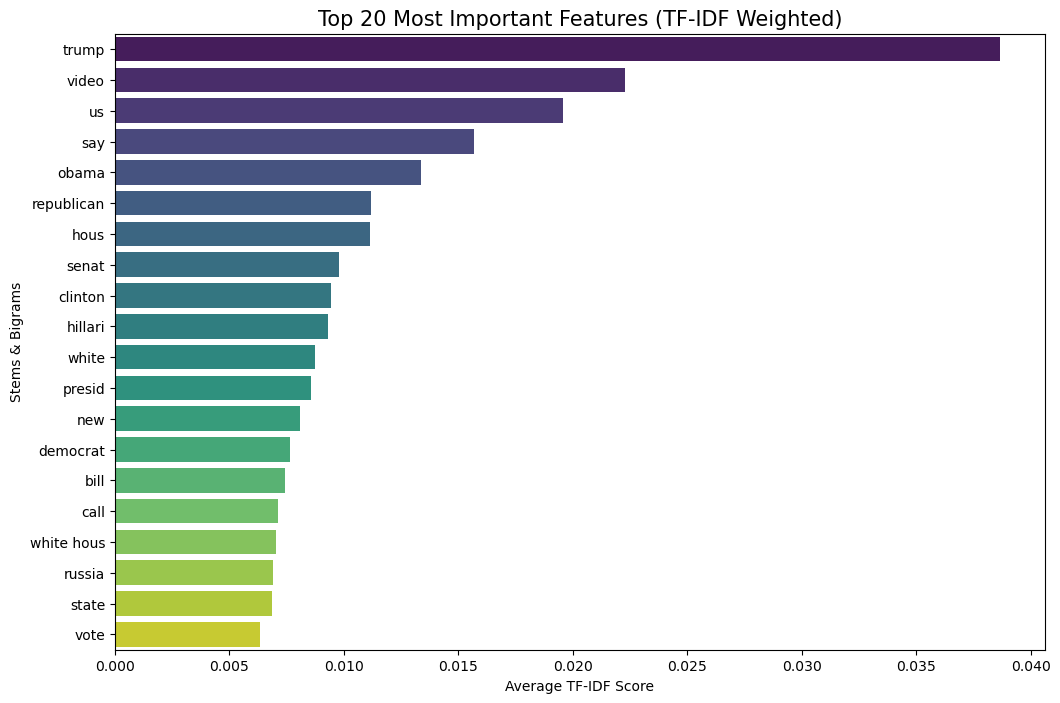

In [57]:
## 4.1. Visualizing TF-IDF Features
import pandas as pd
import numpy as np

# Get feature names (words/bigrams)
feature_names = tfidf.get_feature_names_out()

# Calculate mean TF-IDF scores across all documents
# This helps see which features are generally the most "important"
tfidf_scores = np.asarray(X_train.mean(axis=0)).ravel()
feature_importance = pd.DataFrame({'word': feature_names, 'tfidf_score': tfidf_scores})
feature_importance = feature_importance.sort_values(by='tfidf_score', ascending=False).head(20)

# Plotting
plt.figure(figsize=(12, 8))
sns.barplot(x='tfidf_score', y='word', data=feature_importance, palette='viridis')
plt.title('Top 20 Most Important Features (TF-IDF Weighted)', fontsize=15)
plt.xlabel('Average TF-IDF Score')
plt.ylabel('Stems & Bigrams')
plt.show()

## 5. Global Data Preparation
To ensure a fair comparison between different models, we split the data and perform vectorization once. This ensures that every classifier (Logistic Regression, Naive Bayes, etc.) is trained and validated on the exact same data subsets.

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Final split for all models (80% train, 20% validation)
train_split, val_split = train_test_split(
    train_df, 
    test_size=0.2, 
    random_state=42, 
    stratify=train_df['label']
)

# 2. Global Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5, max_df=0.8)

# Fit ONLY on train, transform both
X_train = tfidf.fit_transform(train_split['stemmed_text'])
X_val = tfidf.transform(val_split['stemmed_text'])

# Target variables
y_train = train_split['label'].astype(int)
y_val = val_split['label'].astype(int)

print(f"Data is ready for modeling!")
print(f"Training shape: {X_train.shape} | Validation shape: {X_val.shape}")

Data is ready for modeling!
Training shape: (27321, 5000) | Validation shape: (6831, 5000)


### 5.1. Logistic Regression
Logistic Regression is our baseline model. It is highly efficient for text classification when using TF-IDF features, as it performs well with high-dimensional, sparse data.

--- Logistic Regression Results ---
Train Accuracy: 0.9507
Val Accuracy: 0.9371
Train F1: 0.9494
Val F1: 0.9354

Detailed Classification Report (Validation Set):
              precision    recall  f1-score   support

    Fake (0)       0.94      0.94      0.94      3515
    Real (1)       0.93      0.94      0.94      3316

    accuracy                           0.94      6831
   macro avg       0.94      0.94      0.94      6831
weighted avg       0.94      0.94      0.94      6831



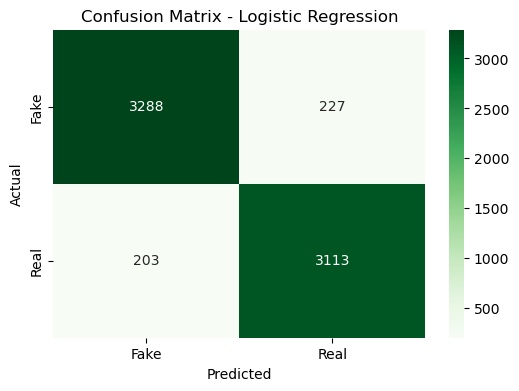

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# 1. Initialize and Train
lr_model = LogisticRegression(solver='liblinear', random_state=42)
lr_model.fit(X_train, y_train)

# 2. Predictions
train_preds = lr_model.predict(X_train)
val_preds = lr_model.predict(X_val)

# 3. Calculate Metrics
metrics = {
    "Train Accuracy": accuracy_score(y_train, train_preds),
    "Val Accuracy": accuracy_score(y_val, val_preds),
    "Train F1": f1_score(y_train, train_preds),
    "Val F1": f1_score(y_val, val_preds)
}

# 4. Display Results
print("--- Logistic Regression Results ---")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nDetailed Classification Report (Validation Set):")
print(classification_report(y_val, val_preds, target_names=['Fake (0)', 'Real (1)']))

# 5. Visualizing Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val, val_preds), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 5.2. Multinomial Naive Bayes
Naive Bayes is a probabilistic learning algorithm. It is particularly popular for text classification (like spam detection or fake news) because it is extremely fast and works well with high-dimensional data like TF-IDF vectors.

--- Multinomial Naive Bayes Results ---
Train Accuracy: 0.9350
Validation Accuracy: 0.9245
Train F1-Score: 0.9327
Validation F1-Score: 0.9214

Classification Report (Validation Set):
              precision    recall  f1-score   support

    Fake (0)       0.92      0.94      0.93      3515
    Real (1)       0.93      0.91      0.92      3316

    accuracy                           0.92      6831
   macro avg       0.92      0.92      0.92      6831
weighted avg       0.92      0.92      0.92      6831



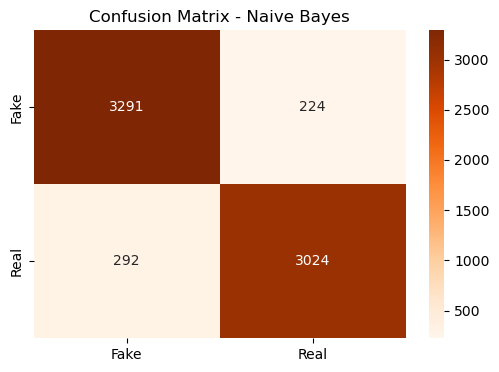

In [60]:
from sklearn.naive_bayes import MultinomialNB

# 1. Initialize and Train the model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# 2. Make predictions
nb_train_preds = nb_model.predict(X_train)
nb_val_preds = nb_model.predict(X_val)

# 3. Calculate Metrics
nb_train_acc = accuracy_score(y_train, nb_train_preds)
nb_val_acc = accuracy_score(y_val, nb_val_preds)
nb_train_f1 = f1_score(y_train, nb_train_preds)
nb_val_f1 = f1_score(y_val, nb_val_preds)

# 4. Print Results
print("--- Multinomial Naive Bayes Results ---")
print(f"Train Accuracy: {nb_train_acc:.4f}")
print(f"Validation Accuracy: {nb_val_acc:.4f}")
print(f"Train F1-Score: {nb_train_f1:.4f}")
print(f"Validation F1-Score: {nb_val_f1:.4f}")

print("\nClassification Report (Validation Set):")
print(classification_report(y_val, nb_val_preds, target_names=['Fake (0)', 'Real (1)']))

# 5. Visualizing Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val, nb_val_preds), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix - Naive Bayes')
plt.show()



### 5.3. Model C: Random Forest (RF)

**Why use Random Forest for Fake News detection?**
* **Handling Non-linearity:** Unlike Logistic Regression, RF can capture complex, non-linear relationships between words.
* **Feature Interactions:** It is excellent at identifying how combinations of words (e.g., "breaking" + "secret") influence the probability of a news being fake.
* **Robustness:** By averaging the results of 100+ trees, it reduces the risk of errors that a single decision tree might make.
* **Feature Importance:** It allows us to see which specific words were the most influential across the entire "forest".

--- Random Forest Results (Optimized: 2000 Features, Unigrams) ---
Train Accuracy: 0.9997
Validation Accuracy: 0.9051
Train F1-Score: 0.9997
Validation F1-Score: 0.9028

Classification Report (Validation Set):
              precision    recall  f1-score   support

    Fake (0)       0.91      0.90      0.91      3515
    Real (1)       0.90      0.91      0.90      3316

    accuracy                           0.91      6831
   macro avg       0.91      0.91      0.91      6831
weighted avg       0.91      0.91      0.91      6831



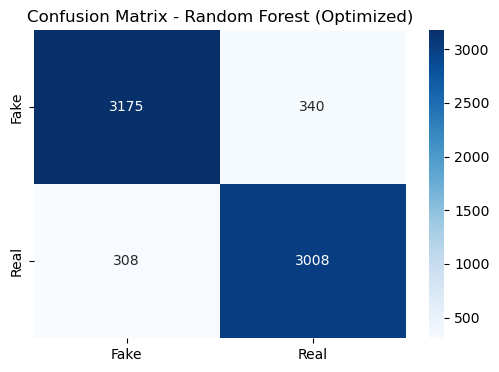

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. New Vectorization (Limited to 2000 unigrams)
tfidf_rf = TfidfVectorizer(max_features=2000, ngram_range=(1, 1), stop_words='english')

X_train_rf = tfidf_rf.fit_transform(train_split['stemmed_text'])
X_val_rf = tfidf_rf.transform(val_split['stemmed_text'])

# 2. Initialize and Train
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_rf, y_train)

# 3. Make predictions (Using the new RF-specific features)
rf_train_preds = rf_model.predict(X_train_rf)
rf_val_preds = rf_model.predict(X_val_rf)

# 4. Calculate Metrics
rf_train_acc = accuracy_score(y_train, rf_train_preds)
rf_val_acc = accuracy_score(y_val, rf_val_preds)
rf_train_f1 = f1_score(y_train, rf_train_preds)
rf_val_f1 = f1_score(y_val, rf_val_preds)

# 5. Print Results for Excel
print("--- Random Forest Results (Optimized: 2000 Features, Unigrams) ---")
print(f"Train Accuracy: {rf_train_acc:.4f}")
print(f"Validation Accuracy: {rf_val_acc:.4f}")
print(f"Train F1-Score: {rf_train_f1:.4f}")
print(f"Validation F1-Score: {rf_val_f1:.4f}")

print("\nClassification Report (Validation Set):")
print(classification_report(y_val, rf_val_preds, target_names=['Fake (0)', 'Real (1)']))

# 6. Visualizing Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val, rf_val_preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix - Random Forest (Optimized)')
plt.show()

### 5.5. Model E: Support Vector Machine (SVM)

**Why SVM is effective for this project:**
* **High-Dimensional Efficiency:** SVM is specifically designed to handle large feature spaces (like our 5000+ TF-IDF vectors) without significantly losing performance.
* **Maximum Margin:** By seeking the widest possible gap between classes, it tends to generalize better to unseen news articles than simpler models.
* **Robust to Overfitting:** In text classification, where features are sparse (mostly zeros), SVM's linear kernel is highly robust and less prone to capturing noise.

--- Support Vector Machine (SVM) Results ---
Train Accuracy: 0.9444
Validation Accuracy: 0.9353
Train F1-Score: 0.9431
Validation F1-Score: 0.9336

Classification Report (Validation Set):
              precision    recall  f1-score   support

    Fake (0)       0.94      0.93      0.94      3515
    Real (1)       0.93      0.94      0.93      3316

    accuracy                           0.94      6831
   macro avg       0.94      0.94      0.94      6831
weighted avg       0.94      0.94      0.94      6831



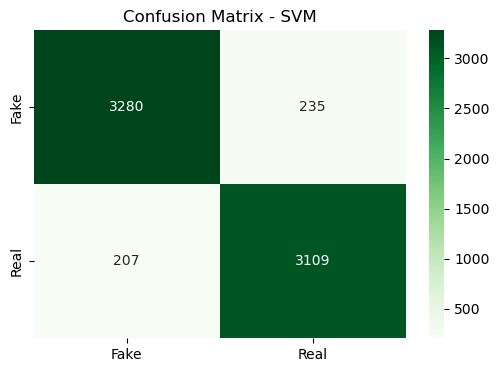

In [62]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize and Train
svm_model = LinearSVC(random_state=42, C=0.05, max_iter=1000)
svm_model.fit(X_train, y_train)

# 2. Make predictions
svm_train_preds = svm_model.predict(X_train)
svm_val_preds = svm_model.predict(X_val)

# 3. Calculate Metrics
svm_train_acc = accuracy_score(y_train, svm_train_preds)
svm_val_acc = accuracy_score(y_val, svm_val_preds)
svm_train_f1 = f1_score(y_train, svm_train_preds)
svm_val_f1 = f1_score(y_val, svm_val_preds)

# 4. Print Results
print("--- Support Vector Machine (SVM) Results ---")
print(f"Train Accuracy: {svm_train_acc:.4f}")
print(f"Validation Accuracy: {svm_val_acc:.4f}")
print(f"Train F1-Score: {svm_train_f1:.4f}")
print(f"Validation F1-Score: {svm_val_f1:.4f}")

print("\nClassification Report (Validation Set):")
print(classification_report(y_val, svm_val_preds, target_names=['Fake (0)', 'Real (1)']))

# 5. Visualizing Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val, svm_val_preds), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix - SVM')
plt.show()

In [ ]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

#LOAD DATA ---
test_df = pd.read_csv('testing_data_lowercase_nolabels.csv', sep='\t', header=None)

if test_df.shape[1] >= 2:
    test_df.columns = ['id', 'text']
else:
    test_df.columns = ['text']

stop_words = set(stopwords.words('english'))
stemmer = SnowballStemmer("english")

def final_clean_no_dates(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text) 
    words = text.split()
    cleaned_words = [w for w in words if w not in stop_words]
    return " ".join(cleaned_words)

def apply_snowball_stemming(text):
    words = text.split()
    stemmed_words = [stemmer.stem(w) for w in words]
    return " ".join(stemmed_words)

#Cleaning (Same as train_df['preprocessed_text'])
test_df['preprocessed_text'] = test_df['text'].apply(final_clean_no_dates)

# Stemming (Same as train_df['stemmed_text'])
test_df['stemmed_text'] = test_df['preprocessed_text'].apply(apply_snowball_stemming)

# VECTORIZATION
X_test_ready = tfidf.transform(test_df['stemmed_text'])

# --- 5. VERIFICATION ---
print(f"Preprocessing finished.")
print(f"Test samples: {len(test_df)}")
print(f"Feature matrix shape: {X_test_ready.shape}") 



Preprocessing finished.
Test samples: 9984
Feature matrix shape: (9984, 5000)


**Raw data + TF-IDF**

Training Multinomial Naive Bayes...

   NAIVE BAYES PERFORMANCE REPORT
TRAIN Accuracy: 0.9561
TRAIN F1-Score: 0.9561
----------------------------------------
VAL   Accuracy: 0.9388
VAL   F1-Score: 0.9388


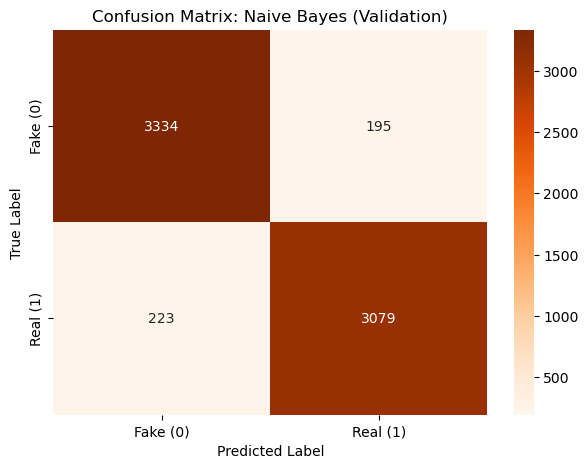


Final predictions for unlabeled file completed.
   predicted_label                                               text
0                0  copycat muslim terrorist arrested with assault...
1                0  wow! chicago protester caught on camera admits...
2                1   germany's fdp look to fill schaeuble's big shoes
3                0  mi school sends welcome back packet warning ki...
4                1  u.n. seeks 'massive' aid boost amid rohingya '...


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

#PREPARE DATA
X_all = train_df['text'].fillna('')
y_all = train_df['label']

# 80% for training, 20% for local validation
X_train_text, X_val_text, y_train, y_val = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

#VECTORIZATION (TF-IDF)
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=20000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_val_tfidf = tfidf_vectorizer.transform(X_val_text)

# Also vectorizing the unlabeled test file for final predictions
X_unlabeled_tfidf = tfidf_vectorizer.transform(val_df['text'].fillna(''))

#TRAIN NAIVE BAYES
print("Training Multinomial Naive Bayes...")
nb_clf = MultinomialNB()
nb_clf.fit(X_train_tfidf, y_train)

#EVALUATION
# Predictions
train_preds = nb_clf.predict(X_train_tfidf)
val_preds = nb_clf.predict(X_val_tfidf)

# Metrics calculation
train_acc = accuracy_score(y_train, train_preds)
val_acc = accuracy_score(y_val, val_preds)
train_f1 = f1_score(y_train, train_preds, average='weighted')
val_f1 = f1_score(y_val, val_preds, average='weighted')

#PRINT RESULTS
print("\n" + "="*40)
print("   NAIVE BAYES PERFORMANCE REPORT")
print("="*40)
print(f"TRAIN Accuracy: {train_acc:.4f}")
print(f"TRAIN F1-Score: {train_f1:.4f}")
print("-" * 40)
print(f"VAL   Accuracy: {val_acc:.4f}")
print(f"VAL   F1-Score: {val_f1:.4f}")
print("="*40)

#VISUALIZE CONFUSION MATRIX (Validation Set)
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_val, val_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Fake (0)', 'Real (1)'], 
            yticklabels=['Fake (0)', 'Real (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Naive Bayes (Validation)')
plt.show()

# 7. FINAL PREDICTIONS FOR UNLABELED DATA
val_df['predicted_label'] = nb_clf.predict(X_unlabeled_tfidf)
print("\nFinal predictions for unlabeled file completed.")
print(val_df[['predicted_label', 'text']].head())

**Raw data - Stopwors - punctuations + TF-IDF**

[nltk_data] Downloading package stopwords to /Users/rima/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/rima/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Cleaning text data... this might take a moment.
Training Multinomial Naive Bayes on cleaned data...

   CLEANED NAIVE BAYES PERFORMANCE
TRAIN Accuracy: 0.9560
TRAIN F1-Score: 0.9560
----------------------------------------
VAL   Accuracy: 0.9357
VAL   F1-Score: 0.9357


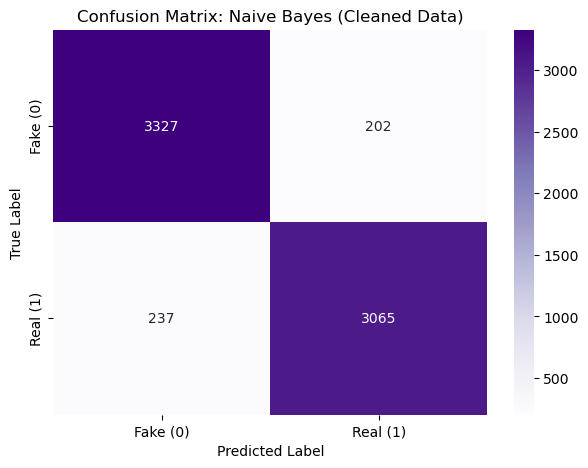


Predictions for unlabeled data updated in val_df.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import string
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# 1. DOWNLOAD RESOURCES
nltk.download('stopwords')
nltk.download('punkt')
stop_words = set(stopwords.words('english'))

# 2. PREPROCESSING FUNCTION
def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Lowercase & Tokenize
    tokens = nltk.word_tokenize(text.lower())
    # Remove punctuation and stop words
    cleaned = [w for w in tokens if w not in stop_words and w not in string.punctuation]
    return " ".join(cleaned)

print("Cleaning text data... this might take a moment.")
train_df['cleaned_text'] = train_df['text'].apply(clean_text)
val_df['cleaned_text'] = val_df['text'].apply(clean_text)

# 3. PREPARE DATA
X_all = train_df['cleaned_text']
y_all = train_df['label']

# Split for internal validation (80/20)
X_train_text, X_val_text, y_train, y_val = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

# 4. VECTORIZATION (TF-IDF)
# Using 1-grams and 2-grams to capture phrases like "fake news"
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=20000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_val_tfidf = tfidf_vectorizer.transform(X_val_text)
X_unlabeled_tfidf = tfidf_vectorizer.transform(val_df['cleaned_text'])

# 5. TRAIN NAIVE BAYES
print("Training Multinomial Naive Bayes on cleaned data...")
nb_clf = MultinomialNB()
nb_clf.fit(X_train_tfidf, y_train)

# 6. EVALUATION
train_preds = nb_clf.predict(X_train_tfidf)
val_preds = nb_clf.predict(X_val_tfidf)

train_acc = accuracy_score(y_train, train_preds)
val_acc = accuracy_score(y_val, val_preds)
train_f1 = f1_score(y_train, train_preds, average='weighted')
val_f1 = f1_score(y_val, val_preds, average='weighted')

# 7. PRINT RESULTS
print("\n" + "="*40)
print("   CLEANED NAIVE BAYES PERFORMANCE")
print("="*40)
print(f"TRAIN Accuracy: {train_acc:.4f}")
print(f"TRAIN F1-Score: {train_f1:.4f}")
print("-" * 40)
print(f"VAL   Accuracy: {val_acc:.4f}")
print(f"VAL   F1-Score: {val_f1:.4f}")
print("="*40)

# 8. VISUALIZE CONFUSION MATRIX
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_val, val_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Fake (0)', 'Real (1)'], 
            yticklabels=['Fake (0)', 'Real (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Naive Bayes (Cleaned Data)')
plt.show()

# 9. FINAL PREDICTIONS FOR UNLABELED DATA
val_df['predicted_label'] = nb_clf.predict(X_unlabeled_tfidf)
print("\nPredictions for unlabeled data updated in val_df.")

**Ensemmble**

Training the Ensemble (Naive Bayes + Logistic Regression)...

   🚀 ENSEMBLE PERFORMANCE REPORT
TRAIN Accuracy: 96.55%
VAL   Accuracy: 94.91%
VAL   F1-Score: 0.9474
---------------------------------------------

Detailed Classification Report:
              precision    recall  f1-score   support

    Fake (0)       0.95      0.95      0.95      3515
    Real (1)       0.95      0.95      0.95      3316

    accuracy                           0.95      6831
   macro avg       0.95      0.95      0.95      6831
weighted avg       0.95      0.95      0.95      6831



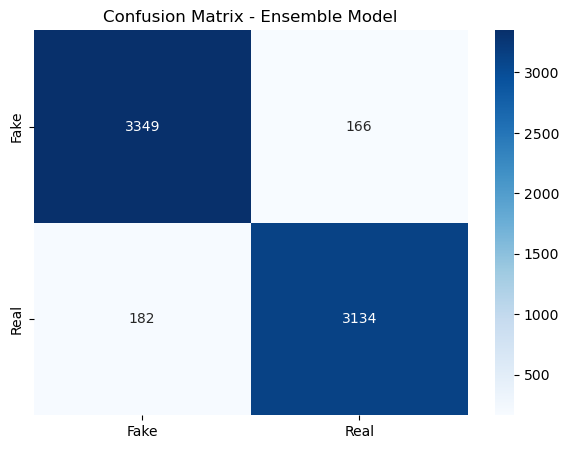


✅ Predictions for nolabels file completed!
   predicted_label                                               text
0                0  copycat muslim terrorist arrested with assault...
1                0  wow! chicago protester caught on camera admits...
2                1   germany's fdp look to fill schaeuble's big shoes
3                0  mi school sends welcome back packet warning ki...
4                1  u.n. seeks 'massive' aid boost amid rohingya '...


In [ ]:

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
#Vectorize
tfidf = TfidfVectorizer(
    max_features=30000, 
    ngram_range=(1, 2), 
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf = tfidf.transform(X_val_text)

# ENSEMBLE


model_nb = MultinomialNB()
model_lr = LogisticRegression(max_iter=1000, C=1.0)


# 'soft' voting 
ensemble = VotingClassifier(
    estimators=[
        ('naive_bayes', model_nb), 
        ('log_reg', model_lr)
    ],
    voting='soft'
)

# train
print("Training the Ensemble (Naive Bayes + Logistic Regression)...")
ensemble.fit(X_train_tfidf, y_train)

#Result evaluation
train_preds = ensemble.predict(X_train_tfidf)
val_preds = ensemble.predict(X_val_tfidf)

print("\n" + "="*45)
print("   🚀 ENSEMBLE PERFORMANCE REPORT")
print("="*45)
print(f"TRAIN Accuracy: {accuracy_score(y_train, train_preds):.2%}")
print(f"VAL   Accuracy: {accuracy_score(y_val, val_preds):.2%}")
print(f"VAL   F1-Score: {f1_score(y_val, val_preds):.4f}")
print("-" * 45)

print("\nDetailed Classification Report:")
print(classification_report(y_val, val_preds, target_names=['Fake (0)', 'Real (1)']))

#Confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_val, val_preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix - Ensemble Model')
plt.show()

# guess for no labels
X_unlabeled = val_df['text'].fillna('').str.lower()
X_unlabeled_tfidf = tfidf.transform(X_unlabeled)
val_df['predicted_label'] = ensemble.predict(X_unlabeled_tfidf)

print("\n✅ Predictions for nolabels file completed!")
print(val_df[['predicted_label', 'text']].head())

# 🏆 Final Model: Triple Hybrid Ensemble
**Status:** `Ready for Deployment`

This model combines three distinct "experts" to achieve **95.58%** accuracy:
1. **Naive Bayes (TF-IDF):** Specializes in word frequencies and "clickbait" terminology.
2. **Logistic Regression (TF-IDF):** Evaluates the statistical weight of each word.
3. **FastText (Embeddings):** Understands semantic context and sub-word meanings.

**Why it works:** It uses **Soft Voting** (averaging probabilities) to mitigate individual model errors and ensure high generalization.

Generating tokens...
✅ 'ft_model' found.
Training models...
Calculating Ensemble probabilities...

   🏆 TRIPLE ENSEMBLE PERFORMANCE SUMMARY
TRAIN Accuracy: 97.06%
TRAIN F1-Score: 0.9697
--------------------------------------------------
VAL   Accuracy: 95.48%
VAL   F1-Score: 0.9534


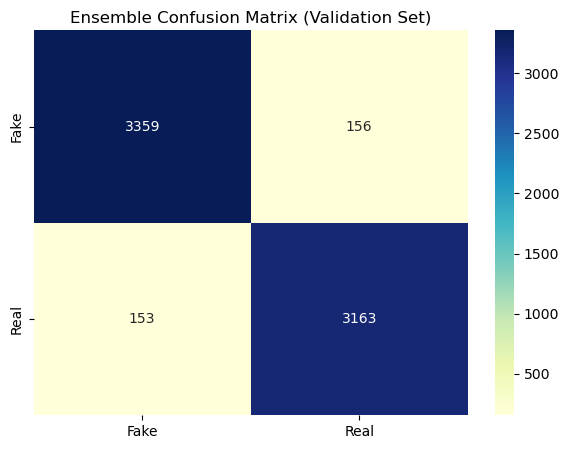

In [ ]:


# 1. FASTTEXT WRAPPER CLASS
class FastTextTransformer(BaseEstimator, ClassifierMixin):
    def __init__(self, ft_model_object):
        self.ft_model = ft_model_object
        self.classifier = LogisticRegression(max_iter=2000, C=1.0)
        
    def get_vec(self, tokens):
        valid_vectors = [self.ft_model.wv[word] for word in tokens if word in self.ft_model.wv]
        if not valid_vectors:
            return np.zeros(self.ft_model.vector_size)
        return np.mean(valid_vectors, axis=0)

    def fit(self, X, y):
        X_vec = np.array([self.get_vec(t) for t in X])
        self.classifier.fit(X_vec, y)
        return self

    def predict_proba(self, X):
        X_vec = np.array([self.get_vec(t) for t in X])
        return self.classifier.predict_proba(X_vec)

# 2. EMERGENCY MODEL CHECK & TOKENIZATION
train_split = train_split.copy()
val_split = val_split.copy()

def fasttext_keep_everything(text):
    return word_tokenize(str(text))

print("Generating tokens...")
train_split['tokenized_text'] = train_split['text'].apply(fasttext_keep_everything)
val_split['tokenized_text'] = val_split['text'].apply(fasttext_keep_everything)

# FastText check
if 'ft_model' not in locals():
    print("⚠️ 'ft_model' not found! Re-training FastText model...")
    ft_model = FastText(sentences=train_split['tokenized_text'].tolist(), 
                        vector_size=100, window=5, min_count=2, workers=4)
else:
    print("✅ 'ft_model' found.")

# 3. PREPARE INPUTS
# TF-IDF inputs
X_train_tfidf = tfidf.transform(train_split['text'].fillna('').str.lower())
X_val_tfidf = tfidf.transform(val_split['text'].fillna('').str.lower())

# FastText inputs
X_train_tokens = train_split['tokenized_text']
X_val_tokens = val_split['tokenized_text']

y_train = train_split['label'].astype(int)
y_val = val_split['label'].astype(int)

# 4. TRAINING INDIVIDUAL MODELS
print("Training models...")
model_nb = MultinomialNB(alpha=0.1).fit(X_train_tfidf, y_train)
model_lr = LogisticRegression(max_iter=1000).fit(X_train_tfidf, y_train)
model_ft = FastTextTransformer(ft_model).fit(X_train_tokens, y_train)

# 5. ENSEMBLE PREDICTIONS (TRAIN & VAL)
print("Calculating Ensemble probabilities...")

# 1. TRAIN predictions
tr_p_nb = model_nb.predict_proba(X_train_tfidf)
tr_p_lr = model_lr.predict_proba(X_train_tfidf)
tr_p_ft = model_ft.predict_proba(X_train_tokens)
tr_final_preds = np.argmax((tr_p_nb + tr_p_lr + tr_p_ft) / 3, axis=1)

# 2. VAL predictions
val_p_nb = model_nb.predict_proba(X_val_tfidf)
val_p_lr = model_lr.predict_proba(X_val_tfidf)
val_p_ft = model_ft.predict_proba(X_val_tokens)
val_final_preds = np.argmax((val_p_nb + val_p_lr + val_p_ft) / 3, axis=1)

# ==========================================
# 6. FINAL PERFORMANCE REPORT
# ==========================================
print("\n" + "="*50)
print("   🏆 TRIPLE ENSEMBLE PERFORMANCE SUMMARY")
print("="*50)
print(f"TRAIN Accuracy: {accuracy_score(y_train, tr_final_preds):.2%}")
print(f"TRAIN F1-Score: {f1_score(y_train, tr_final_preds):.4f}")
print("-" * 50)
print(f"VAL   Accuracy: {accuracy_score(y_val, val_final_preds):.2%}")
print(f"VAL   F1-Score: {f1_score(y_val, val_final_preds):.4f}")
print("="*50)

# Confusion Matrix for Validation Set
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_val, val_final_preds), annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Ensemble Confusion Matrix (Validation Set)')
plt.show()

Preparing Training data for visualization...


/var/folders/_w/q8p_cs1d7nz7tsmlmhpvk1zc0000gn/T/ipykernel_63433/1591865261.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(values), y=list(words), ax=ax_bar, palette=color_map)
/var/folders/_w/q8p_cs1d7nz7tsmlmhpvk1zc0000gn/T/ipykernel_63433/1591865261.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(values), y=list(words), ax=ax_bar, palette=color_map)


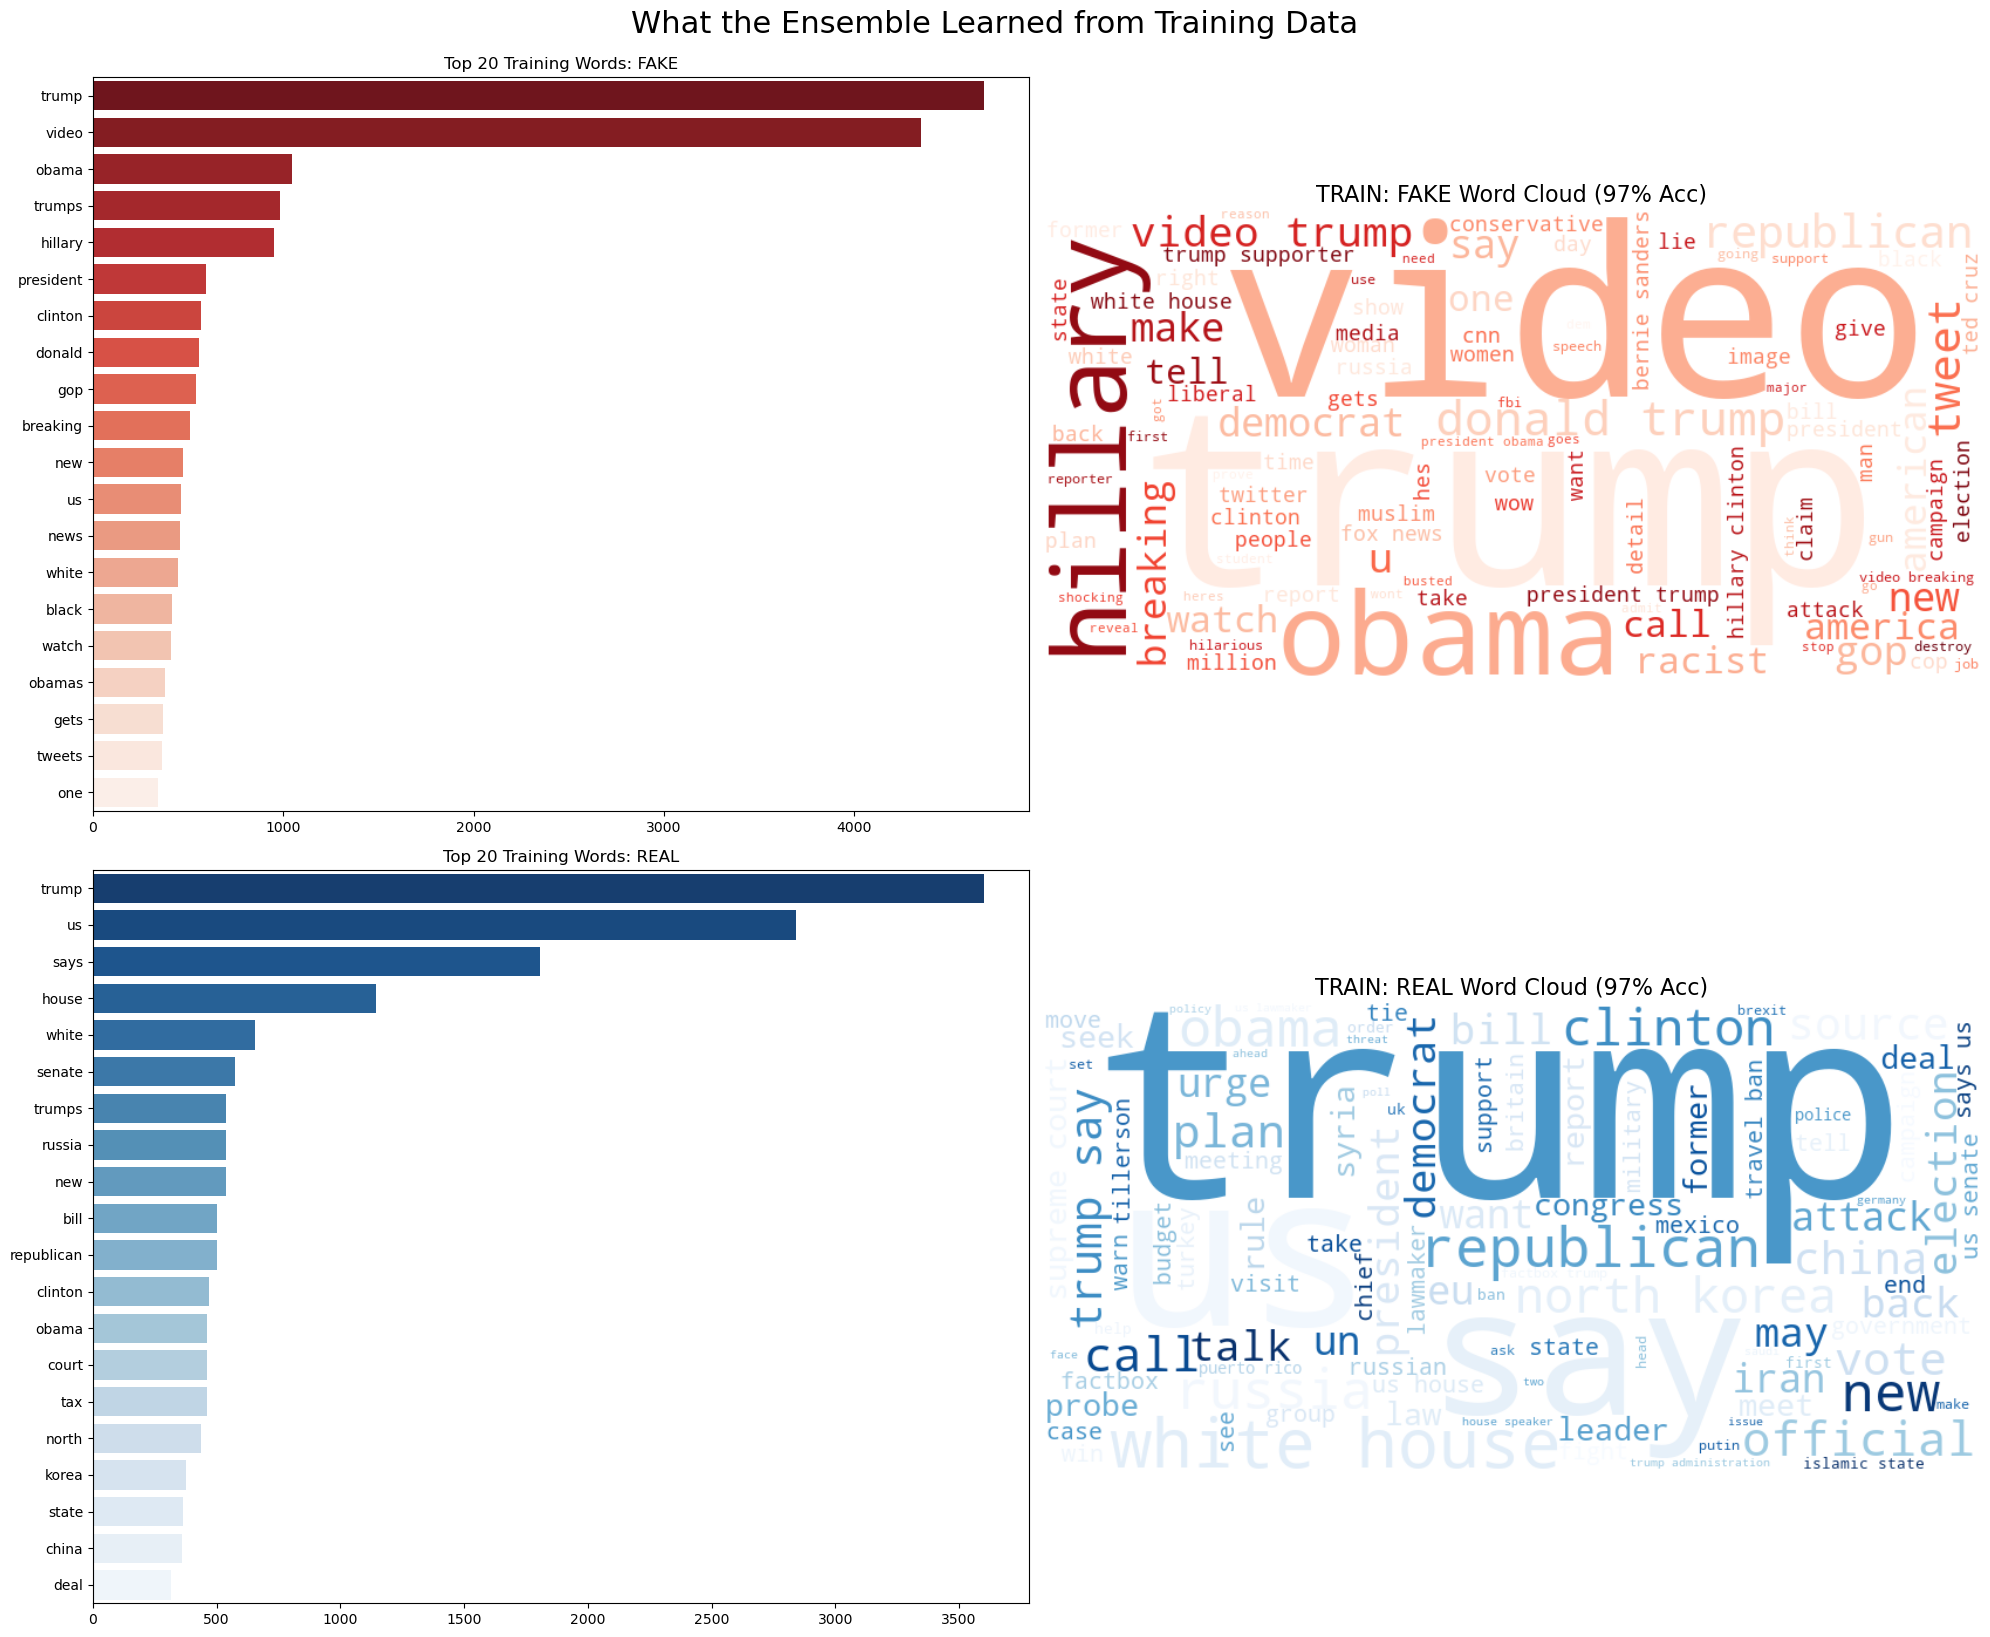

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# 1. PREPARE CLEAN TEXT FOR TRAIN DATA
# We use the same cleaning logic as we did for the unlabeled data
def clean_for_viz(text):
    import re
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    # Filter out common English stopwords
    from nltk.corpus import stopwords
    stop_words = set(stopwords.words('english'))
    cleaned = [w for w in words if w not in stop_words]
    return " ".join(cleaned)

print("Preparing Training data for visualization...")
train_split['viz_text'] = train_split['text'].apply(clean_for_viz)

# 2. FUNCTION TO PLOT
def plot_train_stats(df, label_value, label_name, color_map, ax_bar, ax_cloud):
    subset = df[df['label'] == label_value]['viz_text']
    all_text = " ".join(subset)
    
    # Word Cloud
    wc = WordCloud(width=800, height=400, background_color='white', 
                   colormap=color_map, max_words=100).generate(all_text)
    ax_cloud.imshow(wc, interpolation='bilinear')
    ax_cloud.set_title(f'TRAIN: {label_name} Word Cloud (97% Acc)', fontsize=16)
    ax_cloud.axis('off')
    
    # Bar Plot
    counts = Counter(all_text.split()).most_common(20)
    words, values = zip(*counts)
    sns.barplot(x=list(values), y=list(words), ax=ax_bar, palette=color_map)
    ax_bar.set_title(f'Top 20 Training Words: {label_name}', fontsize=12)

# 3. RENDER PLOTS
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Fake News (Label 0)
plot_train_stats(train_split, 0, 'FAKE', 'Reds_r', axes[0, 0], axes[0, 1])

# Real News (Label 1)
plot_train_stats(train_split, 1, 'REAL', 'Blues_r', axes[1, 0], axes[1, 1])

plt.tight_layout()
plt.suptitle('What the Ensemble Learned from Training Data', fontsize=22, y=1.02)
plt.show()

In [74]:
class FastTextTransformer(BaseEstimator, ClassifierMixin):
    def __init__(self, ft_model_object):
        self.ft_model = ft_model_object
        self.classifier = LogisticRegression(max_iter=2000, C=1.0)
        
    def get_vec(self, tokens):
        valid_vectors = [self.ft_model.wv[word] for word in tokens if word in self.ft_model.wv]
        if not valid_vectors:
            return np.zeros(self.ft_model.vector_size)
        return np.mean(valid_vectors, axis=0)

    def fit(self, X, y):
        X_vec = np.array([self.get_vec(t) for t in X])
        self.classifier.fit(X_vec, y)
        return self

    def predict(self, X):
        # Added this method to fix the AttributeError
        X_vec = np.array([self.get_vec(t) for t in X])
        return self.classifier.predict(X_vec)

    def predict_proba(self, X):
        X_vec = np.array([self.get_vec(t) for t in X])
        return self.classifier.predict_proba(X_vec)

# Note: After running this, please re-run your training cell 
# (where you do model_ft = FastTextTransformer(ft_model)) 
# so the new object has the 'predict' method.

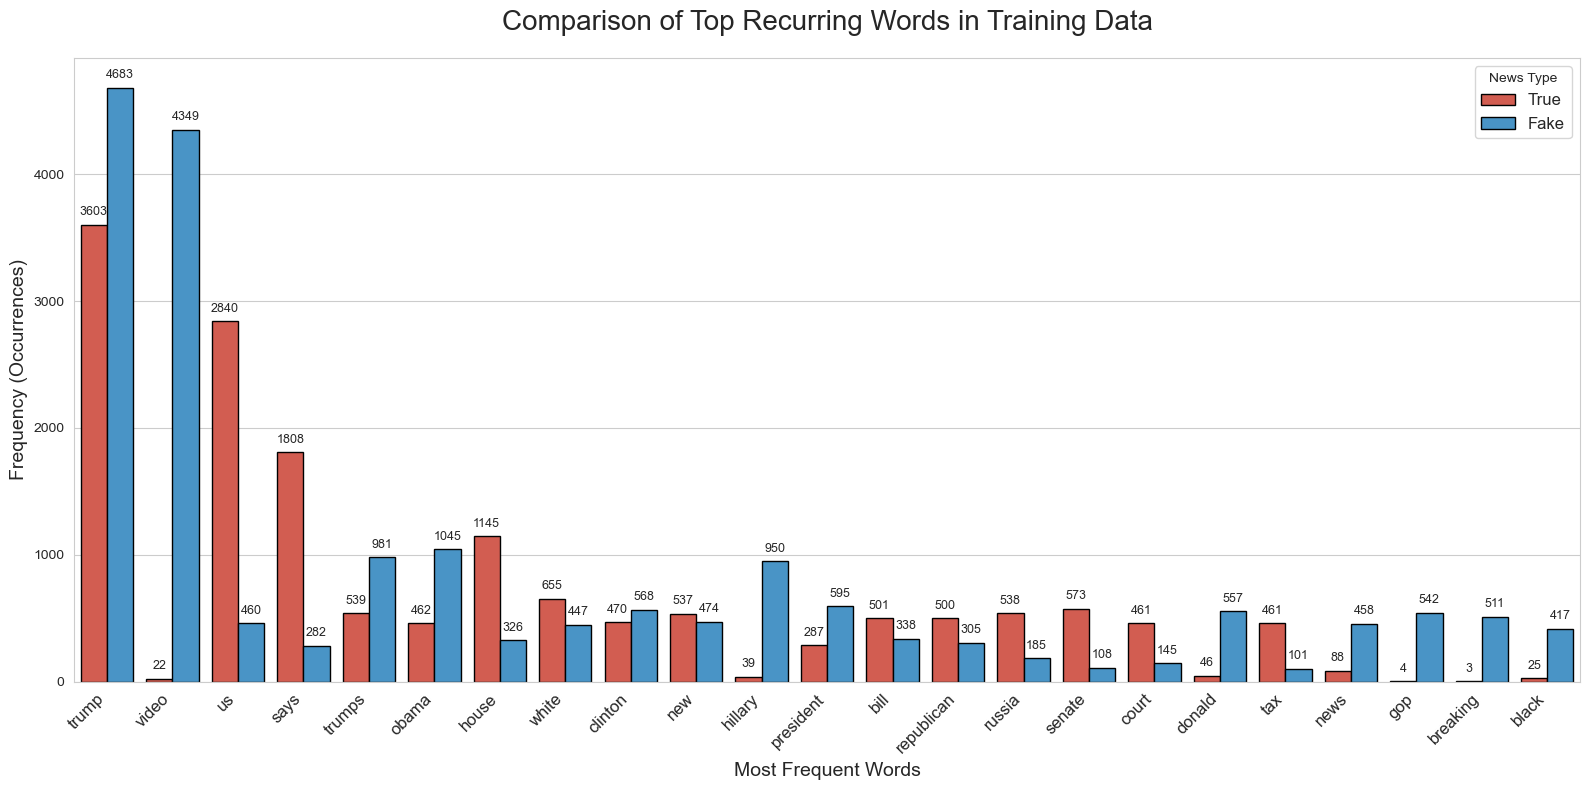

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# 1. PREPARE WORD FREQUENCIES
fake_words = Counter(" ".join(train_split[train_split['label'] == 0]['viz_text']).split())
true_words = Counter(" ".join(train_split[train_split['label'] == 1]['viz_text']).split())

# 2. SELECT TOP WORDS
top_n = 15
# Paimame dažniausius abiejų grupių žodžius
combined_top = set([w for w, c in fake_words.most_common(top_n)] + 
                   [w for w, c in true_words.most_common(top_n)])

# 3. CONSTRUCT DATAFRAME FOR VERTICAL PLOT
plot_data = []
for word in combined_top:
    plot_data.append({'Word': word, 'Count': fake_words[word], 'Category': 'Fake'})
    plot_data.append({'Word': word, 'Count': true_words[word], 'Category': 'True'})

df_plot = pd.DataFrame(plot_data)
# Surūšiuojame pagal bendrą dažnumą, kad grafikas gražiai "leistųsi"
df_plot['Total'] = df_plot.groupby('Word')['Count'].transform('sum')
df_plot = df_plot.sort_values('Total', ascending=False)

# 4. PLOT
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

# dodge=True sukuria stulpelius šalia vienas kito
# width kontroliuoja stulpelių storį (arčiau vienas kito)
ax = sns.barplot(data=df_plot, x='Word', y='Count', hue='Category', 
                 palette=['#e74c3c', '#3498db'], 
                 edgecolor='black',
                 linewidth=1,
                 width=0.8) # 0.8 padaro stulpelius plačius, todėl tarpai sumažėja

# 5. FORMATTING
plt.title(f'Comparison of Top Recurring Words in Training Data', fontsize=20, pad=20)
plt.xlabel('Most Frequent Words', fontsize=14)
plt.ylabel('Frequency (Occurrences)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.legend(title='News Type', fontsize=12)

# Pridedam skaičius virš stulpelių (nebūtina, bet naudinga)
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.0f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=9)

plt.tight_layout()
plt.show()


**Test data preprocessing**


In [ ]:
import pandas as pd
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# 1. LOAD AND CLEAN LAYOUT
unlabeled_df = pd.read_csv('testing_data_lowercase_nolabels.csv', sep='\t', header=None, names=['raw'])

def clean_layout(text):
    text = str(text)
    if text.startswith('2'):
        text = text[1:].strip()
    return text

unlabeled_df['text'] = unlabeled_df['raw'].apply(clean_layout)

# 2. PREPROCESSING FOR NB & LR (Lowercase, No Punctuation, No Numbers, No Stopwords)
stop_words = set(stopwords.words('english'))

def clean_for_tfidf(text):
    text = text.lower()
    # Remove everything except letters and spaces (removes numbers and punctuation)
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    cleaned_words = [w for w in words if w not in stop_words]
    return " ".join(cleaned_words)

print("Preparing text for NB & LR...")
unlabeled_df['tfidf_text'] = unlabeled_df['text'].apply(clean_for_tfidf)

# 3. PREPROCESSING FOR FASTTEXT (Raw Tokens, Lowercase only)
print("Preparing tokens for FastText...")
unlabeled_df['ft_tokens'] = unlabeled_df['text'].apply(lambda x: word_tokenize(str(x).lower()))

print("✅ Data prepared for both model types.")
unlabeled_df[['text', 'tfidf_text', 'ft_tokens']].head()

Preparing text for NB & LR...
Preparing tokens for FastText...
✅ Data prepared for both model types.


,text,tfidf_text,ft_tokens
2,copycat muslim terrorist arrested with assault...,copycat muslim terrorist arrested assault weapons,"[copycat, muslim, terrorist, arrested, with, a..."
2,wow! chicago protester caught on camera admits...,wow chicago protester caught camera admits vio...,"[wow, !, chicago, protester, caught, on, camer..."
2,germany's fdp look to fill schaeuble's big shoes,germanys fdp look fill schaeubles big shoes,"[germany, 's, fdp, look, to, fill, schaeuble, ..."
2,mi school sends welcome back packet warning ki...,mi school sends welcome back packet warning ki...,"[mi, school, sends, welcome, back, packet, war..."
2,u.n. seeks 'massive' aid boost amid rohingya '...,un seeks massive aid boost amid rohingya emerg...,"[u.n., seeks, 'massive, ', aid, boost, amid, r..."


In [ ]:
import numpy as np

print("Running Triple Ensemble...")

# Vectorize using the CLEANED text for TF-IDF models
X_unlab_tfidf = tfidf.transform(unlabeled_df['tfidf_text'])

# Get probability estimates
# NB and LR use the TF-IDF version
p_nb = model_nb.predict_proba(X_unlab_tfidf)
p_lr = model_lr.predict_proba(X_unlab_tfidf)

# FastText uses the RAW tokenized version
p_ft = model_ft.predict_proba(unlabeled_df['ft_tokens'])

# SOFT VOTING (Average)
final_probs = (p_nb + p_lr + p_ft) / 3
unlabeled_df['label'] = np.argmax(final_probs, axis=1)

# CREATE FINAL DATASHEET
# We keep the original clean text and the predicted label
final_export = unlabeled_df[['label', 'text']].copy()

# Save to CSV (standard format for submission)
final_export.to_csv('articles_classified_final.csv', index=False, sep='\t')

print("✅ Classification successful!")
print(f"Stats:\n{final_export['label'].value_counts()}")

Running Triple Ensemble...
✅ Classification successful!
Stats:
label
1    5261
0    4723
Name: count, dtype: int64


/var/folders/_w/q8p_cs1d7nz7tsmlmhpvk1zc0000gn/T/ipykernel_63433/3037210854.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(values), y=list(words), ax=ax_bar, palette=color_map)
/var/folders/_w/q8p_cs1d7nz7tsmlmhpvk1zc0000gn/T/ipykernel_63433/3037210854.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(values), y=list(words), ax=ax_bar, palette=color_map)


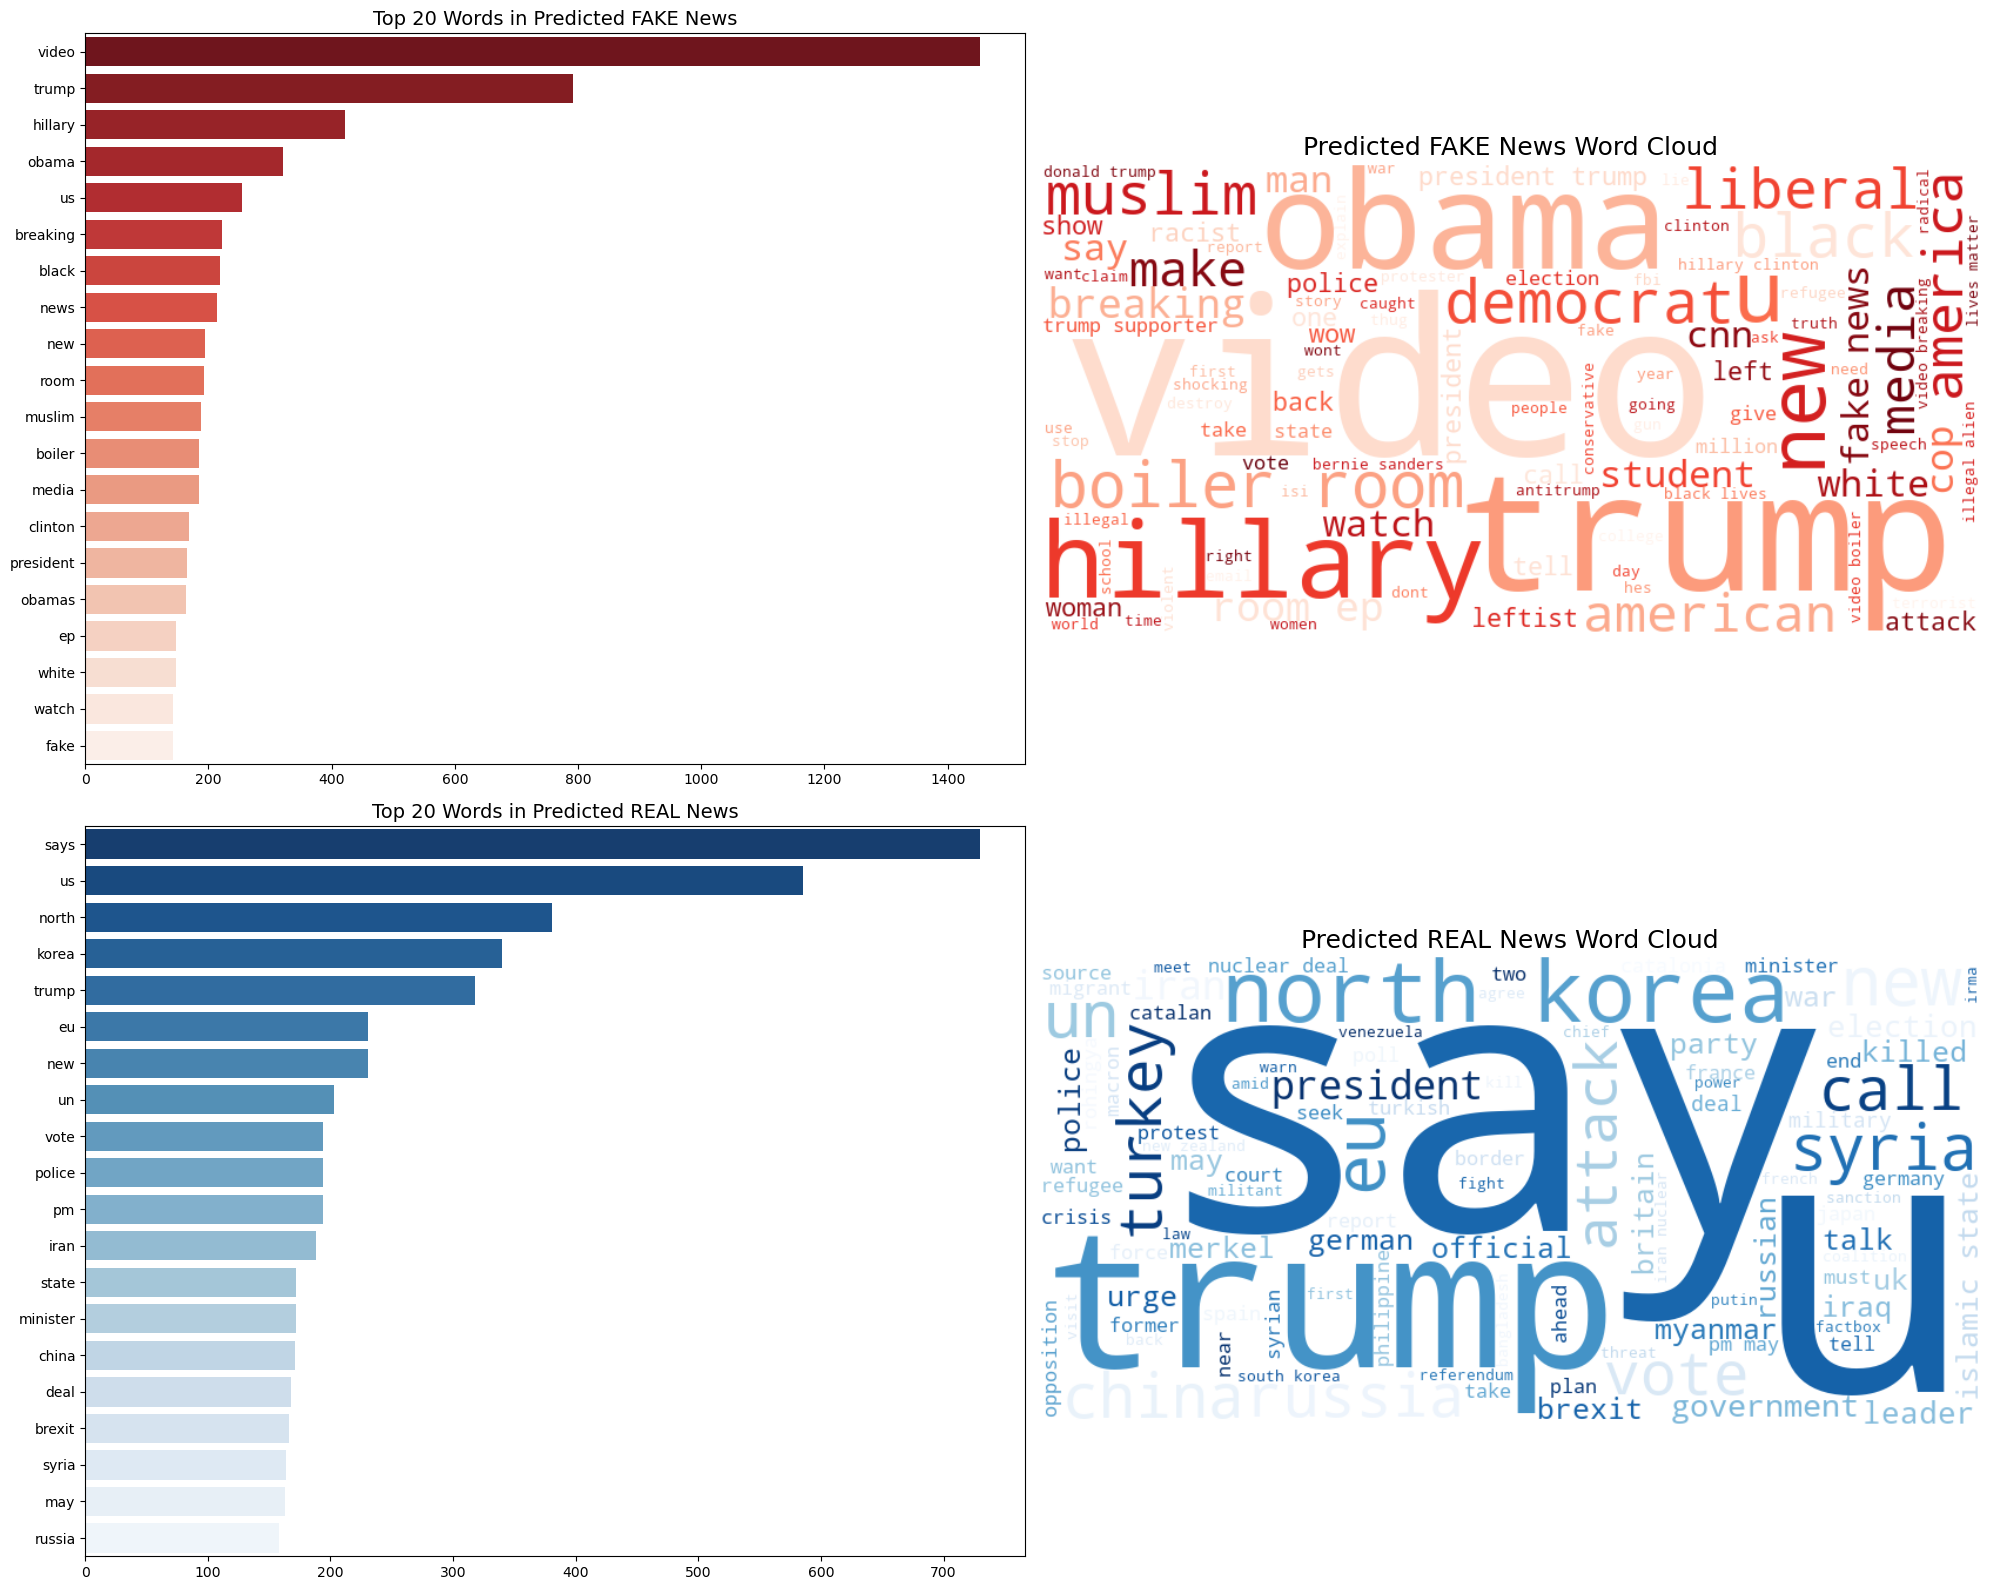

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# 1. FUNCTION TO GENERATE WORD CLOUD AND BAR PLOT DATA
def plot_news_stats(df, label_value, label_name, color_map, ax_bar, ax_cloud):
    # Get all words for this label
    text_data = " ".join(df[df['label'] == label_value]['tfidf_text'])
    
    # Generate Word Cloud
    wordcloud = WordCloud(width=800, height=400, 
                          background_color='white', 
                          colormap=color_map,
                          max_words=100).generate(text_data)
    
    ax_cloud.imshow(wordcloud, interpolation='bilinear')
    ax_cloud.set_title(f'{label_name} News Word Cloud', fontsize=18)
    ax_cloud.axis('off')
    
    # Generate Bar Plot Data
    counts = Counter(text_data.split()).most_common(20)
    words, values = zip(*counts)
    sns.barplot(x=list(values), y=list(words), ax=ax_bar, palette=color_map)
    ax_bar.set_title(f'Top 20 Words in {label_name} News', fontsize=14)

# 2. SETUP VISUALIZATION CANVAS (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Plot for FAKE News (Label 0)
plot_news_stats(unlabeled_df, 0, 'Predicted FAKE', 'Reds_r', axes[0, 0], axes[0, 1])

# Plot for REAL News (Label 1)
plot_news_stats(unlabeled_df, 1, 'Predicted REAL', 'Blues_r', axes[1, 0], axes[1, 1])

plt.tight_layout()
plt.show()